In [ ]:
import os
import cv2
from collections import deque

OUT_DIR = "/kaggle/working/clips_dataset"

CLIP_LEN = 8
STRIDE = 8
FPS = 10

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(f"{OUT_DIR}/violence", exist_ok=True)
os.makedirs(f"{OUT_DIR}/normal", exist_ok=True)



def extract_clips_fast(video_path, label, max_clips=5):
    cap = cv2.VideoCapture(video_path)
    buffer = deque(maxlen=CLIP_LEN)

    clip_count = 0
    frame_idx = 0

    # get video info once
    ret, frame = cap.read()
    if not ret:
        return
    h, w, _ = frame.shape
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_idx += 1
        buffer.append(frame)

        # create clip only when buffer is full
        if len(buffer) == CLIP_LEN:

            # limit number of clips per video (VERY IMPORTANT SPEED BOOST)
            if clip_count >= max_clips:
                break

            out_path = f"{OUT_DIR}/{label}/{hash(video_path)}_{clip_count}.mp4"

            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
            out = cv2.VideoWriter(out_path, fourcc, FPS, (w, h))

            for f in buffer:
                out.write(f)

            out.release()
            clip_count += 1

            # skip frames (FAST STRIDE)
            for _ in range(STRIDE):
                cap.read()

    cap.release()

In [ ]:
rwf_root = "/kaggle/input/datasets/vulamnguyen/rwf2000/RWF-2000"

mapping = {
    "Fight": "violence",
    "NonFight": "normal"
}

for split in ["train", "val"]:
    for cls in os.listdir(f"{rwf_root}/{split}"):

        if cls not in mapping:
            continue

        label = mapping[cls]
        src = f"{rwf_root}/{split}/{cls}"

        print("Processing:", cls)

        for video in os.listdir(src):
            video_path = os.path.join(src, video)

            extract_clips_fast(video_path, label)

Processing: Fight
Processing: NonFight
Processing: Fight
Processing: NonFight


In [ ]:
xd_root = "/kaggle/input/datasets/bypktt/xd-violence"

mapping = {
    "Abuse": "violence",
    "Fighting": "violence",
    "Riot": "violence",
    "Shooting": "violence",
    "Explosion": "violence",
    "Normal": "normal"
}

for split in ["train", "test"]:
    for cls in os.listdir(f"{xd_root}/{split}"):

        if cls not in mapping:
            continue

        label = mapping[cls]
        src = f"{xd_root}/{split}/{cls}"

        print("Processing:", cls)

        for video in os.listdir(src):
            video_path = os.path.join(src, video)

            extract_clips_fast(video_path, label)

Processing: Riot
Processing: Shooting


[mov,mp4,m4a,3gp,3g2,mj2 @ 0x11a2f2c0] Referenced QT chapter track not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x11cd8780] Referenced QT chapter track not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x11cd8780] Referenced QT chapter track not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x11cd8780] Referenced QT chapter track not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x11db0c80] Referenced QT chapter track not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x11cd8780] Referenced QT chapter track not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x116f71c0] Referenced QT chapter track not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x11a2f2c0] Referenced QT chapter track not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x11cd8780] Referenced QT chapter track not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x11a2f2c0] Referenced QT chapter track not found


Processing: Explosion


[mov,mp4,m4a,3gp,3g2,mj2 @ 0x11a30a40] Referenced QT chapter track not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x122d7540] Referenced QT chapter track not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x11cd8780] Referenced QT chapter track not found


Processing: Normal


...

[mov,mp4,m4a,3gp,3g2,mj2 @ 0x11a2f2c0] Referenced QT chapter track not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x11a2f2c0] Referenced QT chapter track not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x11a2f2c0] Referenced QT chapter track not found


Processing: Riot
Processing: Shooting
Processing: Explosion
Processing: Normal


[mov,mp4,m4a,3gp,3g2,mj2 @ 0x116f71c0] Referenced QT chapter track not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x11cd8780] Referenced QT chapter track not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x116f71c0] Referenced QT chapter track not found


Processing: Abuse
Processing: Fighting


[mov,mp4,m4a,3gp,3g2,mj2 @ 0x116f71c0] Referenced QT chapter track not found


In [ ]:
# ==========================================
# UCF-CRIME ALL NORMAL FOLDERS EXTRACTOR
# ==========================================

ucf_normal_paths = [
    "/kaggle/input/datasets/minmints/ufc-crime-full-dataset/Normal_Videos_for_Event_Recognition/Normal_Videos_for_Event_Recognition",
    "/kaggle/input/datasets/minmints/ufc-crime-full-dataset/Testing_Normal_Videos/Testing_Normal_Videos_Anomaly",
    "/kaggle/input/datasets/minmints/ufc-crime-full-dataset/Training-Normal-Videos-Part-1/Training-Normal-Videos-Part-1",
    "/kaggle/input/datasets/minmints/ufc-crime-full-dataset/Training-Normal-Videos-Part-2/Training-Normal-Videos-Part-2"
]

for src_dir in ucf_normal_paths:

    if not os.path.exists(src_dir):
        print(f"⚠️ Path not found, skipping: {src_dir}")
        continue

    print(f"\n🚀 Processing UCF Folder: {os.path.basename(src_dir)}")


    video_files = [f for f in os.listdir(src_dir) if f.endswith(('.mp4', '.avi', '.mkv'))]
    print(f"Found {len(video_files)} videos in this folder.")

    for video in video_files:
        video_path = os.path.join(src_dir, video)


        extract_clips_fast(video_path, label="normal", max_clips=2)

print("\n✅ Done processing all UCF-Crime Normal folders!")


🚀 Processing UCF Folder: Normal_Videos_for_Event_Recognition
Found 50 videos in this folder.

🚀 Processing UCF Folder: Testing_Normal_Videos_Anomaly
Found 150 videos in this folder.

🚀 Processing UCF Folder: Training-Normal-Videos-Part-1
Found 430 videos in this folder.

🚀 Processing UCF Folder: Training-Normal-Videos-Part-2
Found 370 videos in this folder.

✅ Done processing all UCF-Crime Normal folders!


In [ ]:
print("Total Violence Clips:", len(os.listdir(f"{OUT_DIR}/violence")))
print("Total Normal/Crowd Clips:", len(os.listdir(f"{OUT_DIR}/normal")))

Total Violence Clips: 13233
Total Normal/Crowd Clips: 18740


In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split


IMG_SIZE = 224
BATCH_SIZE = 16
OUT_DIR = "/kaggle/working/clips_dataset"

train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


class MallViolenceDataset(Dataset):
    def __init__(self, video_paths, labels, transform=None):
        self.video_paths = video_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]

        cap = cv2.VideoCapture(video_path)
        frames = []

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            if self.transform:
                frame = self.transform(frame)

            frames.append(frame)

        cap.release()

        # Handling في حالة وجود فيديو تالف
        if len(frames) == 0:
            return torch.zeros((3, 8, IMG_SIZE, IMG_SIZE)), torch.tensor(label, dtype=torch.long)

        video_tensor = torch.stack(frames)


        video_tensor = video_tensor.permute(1, 0, 2, 3)

        return video_tensor, torch.tensor(label, dtype=torch.long)

In [ ]:
all_paths = []
all_labels = []

for label_idx, label_name in enumerate(["normal", "violence"]):
    class_dir = os.path.join(OUT_DIR, label_name)
    for video_name in os.listdir(class_dir):
        all_paths.append(os.path.join(class_dir, video_name))
        all_labels.append(label_idx)


train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels)

train_dataset = MallViolenceDataset(train_paths, train_labels, transform=train_transforms)
val_dataset = MallViolenceDataset(val_paths, val_labels, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"📊 Train Batches: {len(train_loader)} | Val Batches: {len(val_loader)}")

📊 Train Batches: 1599 | Val Batches: 400


In [ ]:
import torch
import torch.nn as nn
from torchvision.models.video import swin3d_t, Swin3D_T_Weights

def get_fine_tuned_swin3d():

    weights = Swin3D_T_Weights.KINETICS400_V1
    model = swin3d_t(weights=weights)

    in_features = model.head.in_features
    model.head = nn.Linear(in_features, 2)

    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_fine_tuned_swin3d()
model = model.to(device)

print(f"✅ Video Swin Transformer is loaded on: {device}")

✅ Video Swin Transformer is loaded on: cuda


In [ ]:
import torch.optim as optim
from torch.amp import autocast, GradScaler


criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

scaler = GradScaler()
NUM_EPOCHS = 10

print("🚀 Starting Training Loop using Video Swin Transformer...")

for epoch in range(NUM_EPOCHS):

    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()


        with autocast(device_type='cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)


        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()


        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_preds += torch.sum(preds == labels.data)
        total_samples += inputs.size(0)

    epoch_train_loss = running_loss / total_samples
    epoch_train_acc = correct_preds.double() / total_samples


    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            with autocast(device_type='cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data)
            val_total += inputs.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct.double() / val_total

    scheduler.step()


    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")


    if epoch == 0 or epoch_val_acc > best_acc:
        best_acc = epoch_val_acc
        torch.save(model.state_dict(), "best_mall_violence_transformer.pth")
        print("💾 Best Model Saved!")

🚀 Starting Training Loop using Video Swin Transformer...
Epoch [1/10] -> Train Loss: 0.4280 | Train Acc: 0.7949 || Val Loss: 0.3151 | Val Acc: 0.8651
💾 Best Model Saved!
Epoch [2/10] -> Train Loss: 0.2345 | Train Acc: 0.9070 || Val Loss: 0.1854 | Val Acc: 0.9281
💾 Best Model Saved!
Epoch [3/10] -> Train Loss: 0.1323 | Train Acc: 0.9495 || Val Loss: 0.1187 | Val Acc: 0.9570
💾 Best Model Saved!
Epoch [4/10] -> Train Loss: 0.0818 | Train Acc: 0.9703 || Val Loss: 0.0908 | Val Acc: 0.9681
💾 Best Model Saved!
Epoch [5/10] -> Train Loss: 0.0640 | Train Acc: 0.9769 || Val Loss: 0.0662 | Val Acc: 0.9792
💾 Best Model Saved!
Epoch [6/10] -> Train Loss: 0.0474 | Train Acc: 0.9840 || Val Loss: 0.0567 | Val Acc: 0.9834
💾 Best Model Saved!
Epoch [7/10] -> Train Loss: 0.0381 | Train Acc: 0.9880 || Val Loss: 0.0502 | Val Acc: 0.9853
💾 Best Model Saved!
Epoch [8/10] -> Train Loss: 0.0349 | Train Acc: 0.9889 || Val Loss: 0.0491 | Val Acc: 0.9851
Epoch [9/10] -> Train Loss: 0.0320 | Train Acc: 0.9895 || V

🔍 Evaluating the best model on Validation Data...


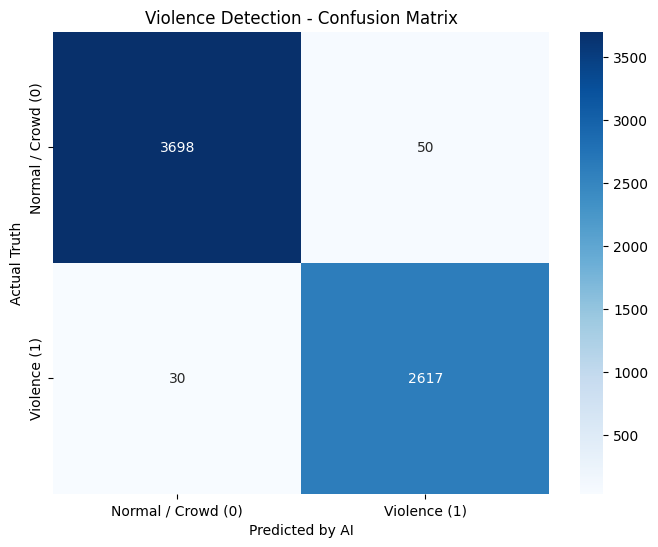


📊 Classification Report:
                    precision    recall  f1-score   support

Normal / Crowd (0)       0.99      0.99      0.99      3748
      Violence (1)       0.98      0.99      0.98      2647

          accuracy                           0.99      6395
         macro avg       0.99      0.99      0.99      6395
      weighted avg       0.99      0.99      0.99      6395



In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

print("🔍 Evaluating the best model on Validation Data...")


model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())


cm = confusion_matrix(all_labels, all_preds)
class_names = ['Normal / Crowd (0)', 'Violence (1)']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted by AI')
plt.ylabel('Actual Truth')
plt.title('Violence Detection - Confusion Matrix')
plt.show()


print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

In [ ]:
import cv2
import torch
from collections import deque
from torchvision import transforms

test_video_path = "/kaggle/input/datasets/adhamdiaa/testter/14.mp4"
output_video_path = "test11.mp4"


cap = cv2.VideoCapture(test_video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))


frame_queue = deque(maxlen=8)
model.eval()

print(f"🎬 Processing Video: {test_video_path}")
print("⚙️ Simulating Real-time Detection...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    display_frame = frame.copy()


    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    transformed_frame = val_transforms(rgb_frame)
    frame_queue.append(transformed_frame)


    if len(frame_queue) == 8:
        video_tensor = torch.stack(list(frame_queue))
        video_tensor = video_tensor.permute(1, 0, 2, 3)
        video_tensor = video_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(video_tensor)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, pred = torch.max(probabilities, 1)

        label_idx = pred.item()
        conf_val = confidence.item()


        if label_idx == 1:
            text = f"VIOLENCE DETECTED ({conf_val*100:.1f}%)"
            color = (0, 0, 255)


            cv2.putText(display_frame, "SYSTEM ALERT: SECURITY DISPATCHED",
                        (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
        else:
            text = f"Normal / Crowd ({conf_val*100:.1f}%)"
            color = (0, 255, 0)


        cv2.rectangle(display_frame, (10, 10), (500, 50), (0, 0, 0), -1)
        cv2.putText(display_frame, text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)


    out.write(display_frame)

cap.release()
out.release()

print(f"✅ Processing Complete! Video saved to: {output_video_path}")
print("📥 You can now download 'live_detection_test.mp4' from the Kaggle output panel to see the results.")

🎬 Processing Video: /kaggle/input/datasets/adhamdiaa/testter/14.mp4
⚙️ Simulating Real-time Detection...
✅ Processing Complete! Video saved to: test11.mp4
📥 You can now download 'live_detection_test.mp4' from the Kaggle output panel to see the results.


In [ ]:
import cv2
import torch
import torch.nn as nn
from collections import deque
from torchvision import transforms
from torchvision.models.video import swin3d_t


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224

inference_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


def load_pure_violence_model(weights_path):

    model = swin3d_t()
    model.head = nn.Linear(model.head.in_features, 2)


    model.load_state_dict(torch.load(weights_path, map_location=device))
    model = model.to(device)
    model.eval()
    return model


def run_violence_detection_only(video_path, weights_path, output_path="result.mp4"):
    model = load_pure_violence_model(weights_path)

    cap = cv2.VideoCapture(video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_queue = deque(maxlen=8)
    print(f"🔄 Processing Video using Video Swin Transformer...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        display_frame = frame.copy()


        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        transformed_frame = inference_transforms(rgb_frame)
        frame_queue.append(transformed_frame)


        if len(frame_queue) == 8:
            video_tensor = torch.stack(list(frame_queue))
            video_tensor = video_tensor.permute(1, 0, 2, 3).unsqueeze(0).to(device)

            with torch.no_grad():
                outputs = model(video_tensor)
                probabilities = torch.softmax(outputs, dim=1)
                confidence, pred = torch.max(probabilities, 1)

            label = "⚠️ VIOLENCE DETECTED" if pred.item() == 1 else "Normal / Crowd"
            color = (0, 0, 255) if pred.item() == 1 else (0, 255, 0)


            text = f"{label} ({confidence.item()*100:.1f}%)"
            cv2.rectangle(display_frame, (10, 10), (450, 55), (0, 0, 0), -1)
            cv2.putText(display_frame, text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

        out.write(display_frame)

    cap.release()
    out.release()
    print(f"✨ Done! Output video is saved at: {output_path}")


# my_weights = "best_mall_violence_transformer.pth"
# my_video = "any_new_test_video.mp4"
# run_violence_detection_only(my_video, my_weights, "pure_inference_output.mp4")